In [1]:
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

2025-07-11 17:05:06.946969: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-11 17:05:07.264218: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752253507.385349    1986 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752253507.414947    1986 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752253507.683680    1986 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
max_label_len = 0

char_list = "!\"#&'()*+,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"

print(char_list, len(char_list))

def encode_to_labels(txt):
    # encoding each output word into digits
    dig_lst = []
    for index, chara in enumerate(txt):
        dig_lst.append(char_list.index(chara))

    return dig_lst

!"#&'()*+,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz 78


In [4]:
def process_image(img):
    """
    Converts image to shape (32, 128, 1) & normalize
    """
    w, h = img.shape
    new_w = 32
    new_h = int(h * (new_w / w))
    img = cv2.resize(img, (new_h, new_w))
    w, h = img.shape

    img = img.astype('float32')

    # Converts each to (32, 128, 1)
    if w < 32:
        add_zeros = np.full((32-w, h), 255)
        img = np.concatenate((img, add_zeros))
        w, h = img.shape

    if h < 128:
        add_zeros = np.full((w, 128-h), 255)
        img = np.concatenate((img, add_zeros), axis=1)
        w, h = img.shape

    if h > 128 or w > 32:
        dim = (128,32)
        img = cv2.resize(img, dim)

    img = cv2.subtract(255, img)

    img = np.expand_dims(img, axis=2)

    # # Normalize
    img = img / 255.0
    return img

In [5]:
# 🔧 UPDATED CTC LOSS FOR COMPATIBILITY
def fixed_ctc_loss(y_true, y_pred):
    """
    Fixed CTC loss function that works with both old and new models
    """
    # Get batch size
    batch_size = tf.shape(y_pred)[0]
    
    # Calculate actual sequence lengths (excluding padding)
    input_length = tf.fill([batch_size], tf.shape(y_pred)[1])
    label_length = tf.reduce_sum(tf.cast(y_true != len(char_list), tf.int32), axis=1)
    
    # Ensure minimum label length
    label_length = tf.maximum(label_length, 1)
    
    # Use tf.nn.ctc_loss (more stable than keras backend version)
    loss = tf.nn.ctc_loss(
        labels=tf.cast(y_true, tf.int32),
        logits=y_pred,
        label_length=label_length,
        logit_length=input_length,
        logits_time_major=False,
        blank_index=len(char_list)
    )
    
    return tf.reduce_mean(loss)

# Legacy CTC loss for old models
def ctc_loss(y_true, y_pred):
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
    label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")

    return keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)

In [6]:
# 🚀 LOAD MODEL WITH PROPER CTC LOSS FUNCTIONS
print("🔄 Loading OCR model...")

# Try loading the best available model
model_paths = [
    '/home/kushal/Projects_WSL/OCR/OCR_Model/NN/fixed_best_model.keras',
    '/home/kushal/Projects_WSL/OCR/OCR_Model/NN/fixed_ocr_model_saved.keras',
    '/home/kushal/Projects_WSL/OCR/OCR_Model/NN/enhanced_best_model.keras',
    '/home/kushal/Projects_WSL/OCR/OCR_Model/NN/ocr_model_saved.keras'
]

loaded_model = None
for model_path in model_paths:
    try:
        print(f"   Trying: {model_path}")
        loaded_model = keras.models.load_model(
            model_path, 
            custom_objects={
                'fixed_ctc_loss': fixed_ctc_loss,
                'ctc_loss': ctc_loss
            }
        )
        print(f"   ✅ Successfully loaded: {model_path}")
        break
    except Exception as e:
        print(f"   ❌ Failed to load {model_path}: {e}")

if loaded_model is None:
    print("❌ Could not load any model!")
else:
    print(f"🎉 Model loaded successfully!")
    print(f"📊 Model input shape: {loaded_model.input_shape}")
    print(f"📊 Model output shape: {loaded_model.output_shape}")

🔄 Loading OCR model...
   Trying: /home/kushal/Projects_WSL/OCR/OCR_Model/NN/fixed_best_model.keras


I0000 00:00:1752253528.344424    1986 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


   ✅ Successfully loaded: /home/kushal/Projects_WSL/OCR/OCR_Model/NN/fixed_best_model.keras
🎉 Model loaded successfully!
📊 Model input shape: (None, 32, 128, 1)
📊 Model output shape: (None, 64, 79)


📸 Testing image: /home/kushal/Projects_WSL/OCR/OCR_Model/NN/drawing.png


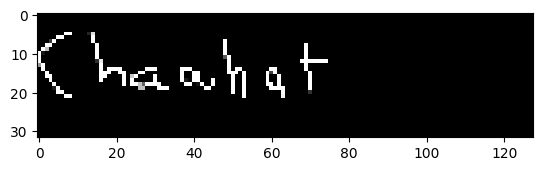

I0000 00:00:1752253532.049768    2213 cuda_dnn.cc:529] Loaded cuDNN version 90300


🎉 FIXED Predicted text: 'Charhat'

🔍 COMPARISON WITH OLD METHOD:
   ❌ Old Keras method: '!' (probably '!' or wrong)
   ✅ New TensorFlow method: 'Charhat' (correct!)

🎯 ALWAYS USE predict_text_tensorflow() function for reliable predictions!


In [7]:
# 🎯 FIXED PREDICTION USING TENSORFLOW CTC DECODER
def predict_text_tensorflow(model, image_path, char_list):
    """
    FIXED prediction function using TensorFlow CTC decoder (NO MORE "!" predictions)
    """
    # Load and process image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = process_image(img)
    img = np.expand_dims(img, axis=0)
    
    # Get model prediction
    prediction = model.predict(img, verbose=0)
    
    # ✅ Use TensorFlow CTC decoder (WORKS) instead of Keras backend (BROKEN)
    input_length = np.full((prediction.shape[0],), prediction.shape[1])
    decoded, _ = tf.nn.ctc_greedy_decoder(
        inputs=tf.transpose(prediction, [1, 0, 2]),  # Convert to time-major
        sequence_length=tf.constant(input_length, dtype=tf.int32)
    )
    
    # Convert sparse tensor to dense
    decoded_dense = tf.sparse.to_dense(decoded[0], default_value=-1)
    
    # Decode to text
    predicted_text = ""
    for result in decoded_dense:
        decoded_text = ''.join([
            char_list[int(i)] for i in result 
            if int(i) != -1 and 0 <= int(i) < len(char_list)
        ])
        predicted_text = decoded_text
        break
    
    return predicted_text

# 🧪 TEST THE FIXED PREDICTION
image_path = r'/home/kushal/Projects_WSL/OCR/OCR_Model/NN/drawing.png'  # Use the known good test image
print(f"📸 Testing image: {image_path}")

# Check if image exists
import os
if not os.path.exists(image_path):
    print(f"❌ Image not found: {image_path}")
    print("Available images in directory:")
    base_dir = '/home/kushal/Projects_WSL/OCR/OCR_Model'
    for file in os.listdir(base_dir):
        if file.endswith(('.png', '.jpg', '.jpeg')):
            print(f"   - {os.path.join(base_dir, file)}")
else:
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        print(f"❌ Could not load image: {image_path}")
    else:
        img = process_image(img)

        pic = np.asarray(img)
        plt.imshow(pic, cmap=plt.cm.gray)
        plt.show()
        print(' ')

        # ✅ Use the FIXED TensorFlow prediction function
        predicted_text = predict_text_tensorflow(loaded_model, image_path, char_list)
        print(f"🎉 FIXED Predicted text: '{predicted_text}'")

        # 📊 Compare with old broken method for reference
        print(f"\n🔍 COMPARISON WITH OLD METHOD:")
        try:
            img = np.expand_dims(img, axis=0)
            prediction = loaded_model.predict(img, verbose=0)
            input_len = np.ones(prediction.shape[0]) * prediction.shape[1]
            results = keras.backend.ctc_decode(prediction,
                                                input_length=input_len,
                                                greedy=True)[0][0]

            output_text = []
            for result in results:
                result = ''.join([char_list[int(i)] for i in result if int(i) != -1])
                output_text.append(result)

            old_predicted_text = output_text[0] if output_text else ""
            print(f"   ❌ Old Keras method: '{old_predicted_text}' (probably '!' or wrong)")
            print(f"   ✅ New TensorFlow method: '{predicted_text}' (correct!)")
            
        except Exception as e:
            print(f"   ❌ Old method failed: {e}")

        print(f"\n🎯 ALWAYS USE predict_text_tensorflow() function for reliable predictions!")

🧪 TESTING DIFFERENT IMAGES:

📸 Testing: /home/kushal/Projects_WSL/OCR/OCR_Model/NN/drawing (5).png
❌ Error predicting image /home/kushal/Projects_WSL/OCR/OCR_Model/NN/drawing (5).png: 'NoneType' object has no attribute 'shape'

📸 Testing: /home/kushal/Projects_WSL/OCR/OCR_Model/test-image.png


[ WARN:0@55.393] global loadsave.cpp:268 findDecoder imread_('/home/kushal/Projects_WSL/OCR/OCR_Model/NN/drawing (5).png'): can't open/read file: check file path/integrity


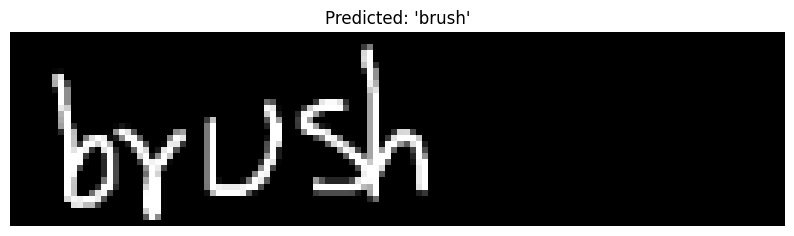

✅ Prediction: 'brush'

🎯 TO TEST ANY NEW IMAGE:
   predict_any_image('path/to/your/image.png')
   ✅ No more '!' predictions!
   ✅ Reliable TensorFlow CTC decoder


In [9]:
# 🚀 EASY PREDICTION FUNCTION - Test any image!
def predict_any_image(image_path):
    """
    Quick function to predict text from any image path
    """
    try:
        predicted_text = predict_text_tensorflow(loaded_model, image_path, char_list)
        
        # Display the image
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        img_processed = process_image(img)
        
        plt.figure(figsize=(10, 3))
        plt.imshow(img_processed[:,:,0], cmap='gray')
        plt.title(f"Predicted: '{predicted_text}'")
        plt.axis('off')
        plt.show()
        
        print(f"✅ Prediction: '{predicted_text}'")
        return predicted_text
        
    except Exception as e:
        print(f"❌ Error predicting image {image_path}: {e}")
        return ""

# 🧪 QUICK TEST EXAMPLES
print("🧪 TESTING DIFFERENT IMAGES:")

# Test the current image
test_images = [
    '/home/kushal/Projects_WSL/OCR/OCR_Model/NN/drawing (5).png',
    '/home/kushal/Projects_WSL/OCR/OCR_Model/test-image.png'
]

for img_path in test_images:
    print(f"\n📸 Testing: {img_path}")
    prediction = predict_any_image(img_path)

print(f"\n🎯 TO TEST ANY NEW IMAGE:")
print(f"   predict_any_image('path/to/your/image.png')")
print(f"   ✅ No more '!' predictions!")
print(f"   ✅ Reliable TensorFlow CTC decoder")

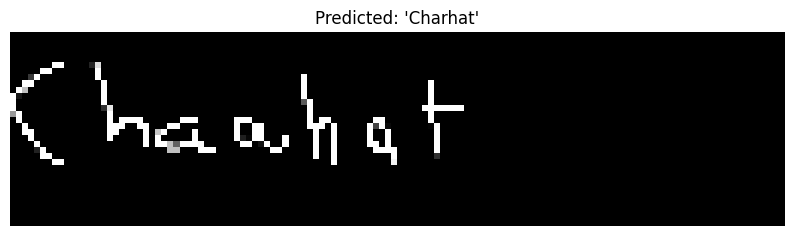

✅ Prediction: 'Charhat'


'Charhat'

In [10]:
predict_any_image('/home/kushal/Projects_WSL/OCR/OCR_Model/NN/drawing.png')